# Histogramas: la huella de una imagen

**Material desarrollado para el IFTS 24 - 2026**

**Espacio:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

En el cuaderno anterior vimos que una imagen es una grilla de números. En este cuaderno vamos a aprender a leer esos números de otra forma: contando cuántos píxeles hay de cada intensidad. Esa cuenta se llama histograma, y es la puerta de entrada para separar objetos del fondo en una imagen.

## Al terminar este material van a poder:

1. Explicar qué representa el histograma de una imagen.
2. Graficar el histograma de una imagen en escala de grises y de sus canales de color.
3. Interpretar la forma de un histograma para diagnosticar brillo y contraste.
4. Reconocer por qué el histograma es el punto de partida para separar objetos del fondo.

## Microglosario

Antes de escribir código, acordemos algunas palabras que van a aparecer todo el tiempo.

| Término | Significado en lenguaje llano |
|---|---|
| Histograma | Un gráfico de barras que cuenta cuántos píxeles hay para cada nivel de intensidad. |
| Intensidad de píxel | El valor numérico que indica qué tan oscuro o claro es un píxel. |
| Bin | Cada barra del histograma; agrupa un rango de intensidades. |
| Contraste | La diferencia entre las zonas más claras y más oscuras de una imagen. |
| Distribución | Cómo se reparten los valores de intensidad a lo largo de toda la imagen. |

## Un histograma como una encuesta

Pensemos en una encuesta de altura tomada a un curso completo. En vez de anotar la altura de cada persona una por una, armamos un gráfico de barras: cuántas personas miden entre 150 y 160 cm, cuántas entre 160 y 170 cm, y así.

Un histograma de imagen hace exactamente eso, pero en vez de personas y altura, cuenta píxeles e intensidad de gris. Cada barra nos dice cuántos píxeles de la imagen tienen ese nivel de oscuridad o claridad.

Esta idea nos va a servir en el próximo cuaderno para trazar una línea de corte sobre esa distribución y separar automáticamente un objeto del fondo.

## 1. Recuperamos el punto de partida

Cada cuaderno de Colab arranca con un entorno nuevo, así que volvemos a cargar las librerías y la imagen con la que veníamos trabajando.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage import color
from skimage import img_as_ubyte

print("✓ Librerías cargadas correctamente.")

✓ Librerías cargadas correctamente.


In [2]:
imagen_color = data.rocket()
imagen_gris = color.rgb2gray(imagen_color)

print("✓ Imagen recuperada.")
print("Forma de la imagen en gris:", imagen_gris.shape)

✓ Imagen recuperada.
Forma de la imagen en gris: (427, 640)


Antes de seguir, mostremos otra vez la imagen en color y su versión en escala de grises, para tener el punto de partida a la vista en este cuaderno. Reutilizamos la misma función `mostrar_imagen` que armamos en el cuaderno anterior.

In [3]:
def mostrar_imagen(imagen, titulo="Imagen", mapa_color=None):
    plt.figure(figsize=(7, 5))
    plt.imshow(imagen, cmap=mapa_color)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

print("✓ Función mostrar_imagen creada correctamente.")

✓ Función mostrar_imagen creada correctamente.


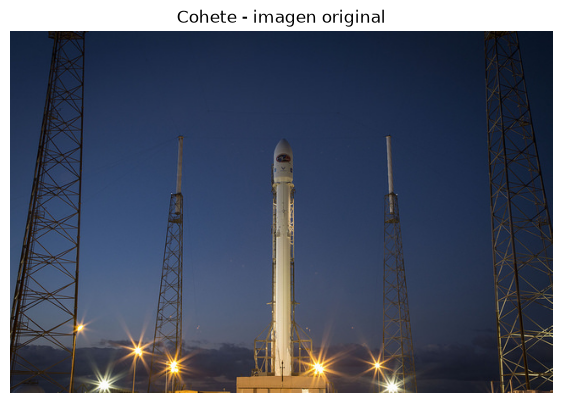

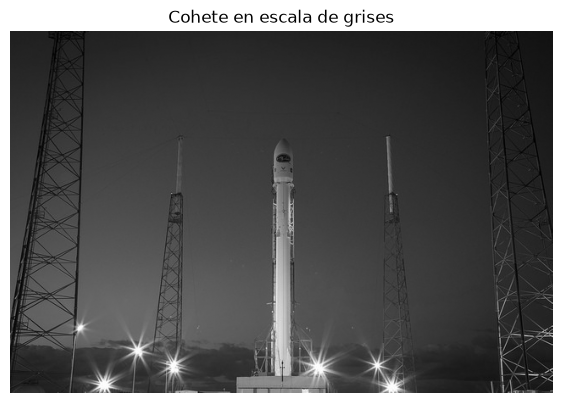

In [4]:
mostrar_imagen(imagen_color, "Cohete - imagen original")
mostrar_imagen(imagen_gris, "Cohete en escala de grises", mapa_color="gray")

## 2. Contamos intensidades a mano

Antes de pedirle a Python que arme el histograma, contemos nosotros mismos sobre una mini imagen inventada de 3x3 píxeles.

In [5]:
mini_imagen = np.array([
    [10, 15, 200],
    [12, 220, 210],
    [8, 190, 205]
])

print("✓ Mini imagen creada")
print(mini_imagen)

✓ Mini imagen creada
[[ 10  15 200]
 [ 12 220 210]
 [  8 190 205]]


Vamos a contar, píxel por píxel, cuántos son oscuros (menor a 100) y cuántos son claros (100 o más). Usamos un bucle `for` para recorrer cada fila y cada valor, así el conteo queda explícito paso a paso.

In [6]:
pixeles_oscuros = 0
pixeles_claros = 0

for fila in mini_imagen:
    for valor in fila:
        if valor < 100:
            pixeles_oscuros = pixeles_oscuros + 1
        else:
            pixeles_claros = pixeles_claros + 1

print("✓ Conteo manual completado")
print("Píxeles oscuros:", pixeles_oscuros)
print("Píxeles claros:", pixeles_claros)

✓ Conteo manual completado
Píxeles oscuros: 4
Píxeles claros: 5


### Para pensar

- Si agrupáramos por rangos más finos (por ejemplo de a 20 en 20) en vez de solo "oscuro/claro", ¿cuántas barras tendría el gráfico?
- ¿Qué pasaría con este conteo si la mini imagen fuera de 100x100 píxeles? ¿Seguiría siendo práctico contar a mano?

## 3. Automatizamos el conteo con matplotlib

Lo que acabamos de hacer a mano es exactamente lo que hace la función `plt.hist`, pero contando los 256 niveles de gris posibles en vez de solo dos grupos.

Para que `plt.hist` reciba los valores de la imagen como una lista simple de números (y no como una grilla de filas y columnas), usamos `.ravel()`, que aplana la imagen en una sola fila.

Hay un detalle importante: `color.rgb2gray` devuelve valores decimales entre 0 y 1, no enteros entre 0 y 255. Para que el histograma se lea con la escala habitual ("0 es negro, 255 es blanco"), convertimos la imagen a 8 bits con `img_as_ubyte` antes de graficarla.

In [7]:
imagen_gris_8bits = img_as_ubyte(imagen_gris)

print("✓ Imagen convertida a 8 bits.")
print("Valor mínimo:", imagen_gris_8bits.min())
print("Valor máximo:", imagen_gris_8bits.max())

✓ Imagen convertida a 8 bits.
Valor mínimo: 0
Valor máximo: 255


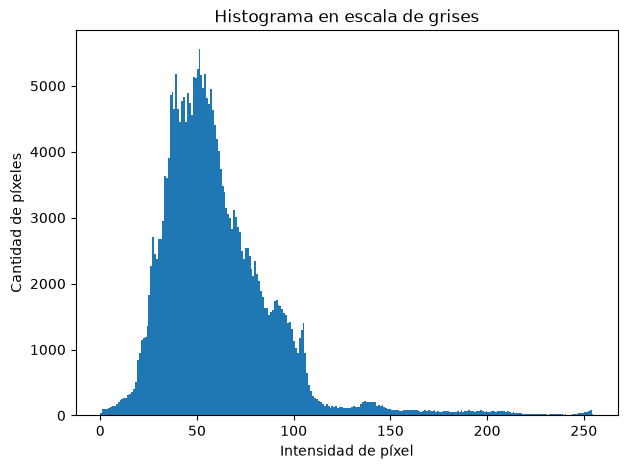

✓ Histograma generado correctamente.


In [8]:
plt.figure(figsize=(7, 5))
plt.hist(imagen_gris_8bits.ravel(), bins=256)
plt.title("Histograma en escala de grises")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Cantidad de píxeles")
plt.show()

print("✓ Histograma generado correctamente.")

### Para pensar

- ¿En qué zona del eje horizontal se concentran la mayoría de los píxeles?
- ¿Eso coincide con lo que veíamos a simple vista en la imagen del cohete en el cuaderno anterior?

## 4. Histograma por canal de color

En el cuaderno anterior separamos la imagen en sus canales rojo, verde y azul. Ahora podemos graficar el histograma de cada canal por separado, para ver cómo se distribuye cada color.

In [9]:
canal_rojo = imagen_color[:, :, 0]
canal_verde = imagen_color[:, :, 1]
canal_azul = imagen_color[:, :, 2]

print("✓ Canales separados nuevamente.")

✓ Canales separados nuevamente.


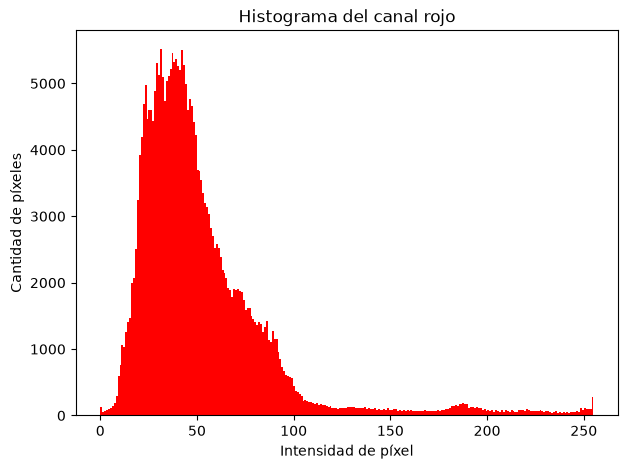

✓ Histograma del canal rojo generado.


In [10]:
plt.figure(figsize=(7, 5))
plt.hist(canal_rojo.ravel(), bins=256, color="red")
plt.title("Histograma del canal rojo")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Cantidad de píxeles")
plt.show()

print("✓ Histograma del canal rojo generado.")

### Para pensar

- Repitan el mismo gráfico para el canal verde y el canal azul (pueden copiar y adaptar la celda anterior en el espacio de práctica).
- ¿Alguno de los tres canales se concentra en valores más altos que los otros? ¿A qué zona de la imagen del cohete le adjudicarían eso?

In [11]:
# ─── Espacio de práctica ──────────────────────────────────────────────────
#
# 1. Grafiquen el histograma del canal verde (canal_verde)
# 2. Grafiquen el histograma del canal azul (canal_azul)
# 3. Agreguen un comentario con la diferencia que observan entre ambos
#
# ─────────────────────────────────────────────────────────────────────────


## 5. Qué nos dice la forma del histograma

Comparemos el histograma del cohete con el de una imagen bien distinta: una foto de la luna, donde predomina el negro del espacio con un cráter iluminado.

In [12]:
imagen_luna = data.moon()

print("✓ Imagen de la luna cargada.")
print("Forma:", imagen_luna.shape)

✓ Imagen de la luna cargada.
Forma: (512, 512)


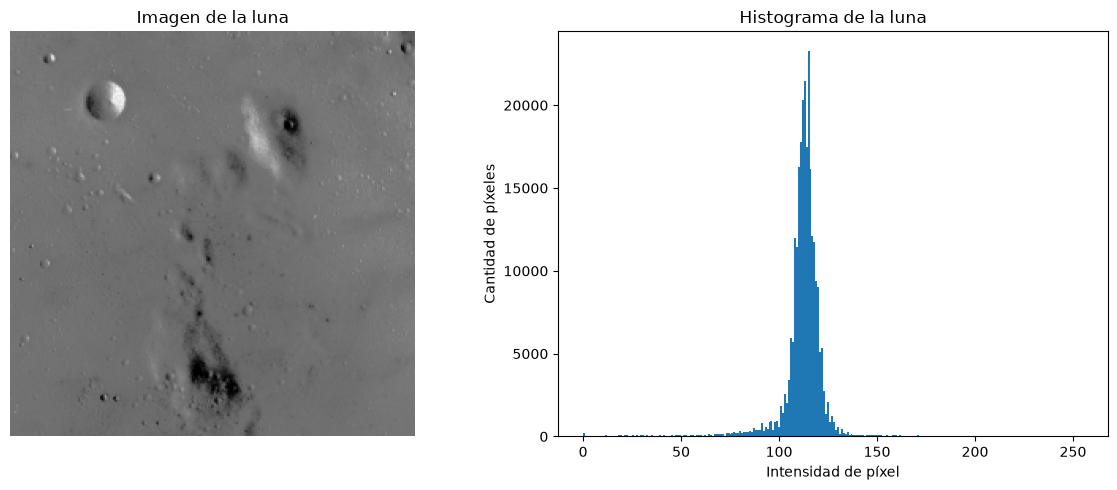

✓ Comparación generada.


In [13]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

eje_imagen = ejes[0]
eje_histograma = ejes[1]

eje_imagen.imshow(imagen_luna, cmap="gray")
eje_imagen.set_title("Imagen de la luna")
eje_imagen.axis("off")

eje_histograma.hist(imagen_luna.ravel(), bins=256)
eje_histograma.set_title("Histograma de la luna")
eje_histograma.set_xlabel("Intensidad de píxel")
eje_histograma.set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

print("✓ Comparación generada.")

### Para pensar

- ¿Hacia qué lado del eje horizontal se acumulan la mayoría de los píxeles en el histograma de la luna?
- ¿Qué le pasaría a este histograma si la foto hubiera sido tomada con más luz ambiente?
- Un histograma cargado hacia la izquierda indica una imagen mayormente oscura. Con esa misma lógica, ¿cómo describirían un histograma cargado hacia la derecha?

## 6. Para qué sirve todo esto

Un histograma no es solo un gráfico decorativo. Se usa para:

- **Diagnosticar brillo y contraste**: un histograma angosto y centrado indica poco contraste; uno disperso en todo el rango indica buen contraste.
- **Ajustar exposición**: las cámaras y las apps de edición usan el histograma para corregir automáticamente imágenes muy oscuras o muy quemadas de luz.
- **Preparar la segmentación**: como vamos a ver en el próximo cuaderno, la forma del histograma nos ayuda a elegir dónde trazar la línea de corte entre "objeto" y "fondo".

## Actividad de producción

Elijan una imagen distinta de `scikit-image` (por ejemplo `data.coffee()`, `data.camera()` o `data.astronaut()`) y produzcan una figura con dos paneles: la imagen a la izquierda y su histograma en escala de grises a la derecha, como hicimos con la imagen de la luna.

Al terminar, agreguen una celda de texto (Markdown) con dos observaciones sobre la forma del histograma que obtuvieron.

In [14]:
# ─── Espacio de práctica: producción final ────────────────────────────────
#
# 1. Elijan una imagen de ejemplo distinta a la del cohete o la luna
# 2. Conviértanla a escala de grises si hace falta (color.rgb2gray)
# 3. Armen una figura de dos paneles: imagen a la izquierda, histograma a la derecha
# 4. Muestren la figura con plt.show()
#
# ─────────────────────────────────────────────────────────────────────────


## Cierre

En este cuaderno aprendimos a leer una imagen a través de su histograma: cuántos píxeles hay en cada nivel de intensidad, y qué nos dice la forma de esa distribución sobre el brillo y el contraste de la imagen.

En el próximo cuaderno vamos a usar esta misma idea para trazar una línea de corte sobre el histograma y separar automáticamente los objetos del fondo: eso se llama umbralización.